## Task 2 ==> Data Preprocessing

<div style="font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #be3125, #ba4c21);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2>🧹 Preprocessing Section</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="font-size:17px; color:#2c3e50;">
Data was cleaned, missing values handled, categorical features encoded, and numerical features scaled to prepare the dataset for modeling.
</p>

</div>

</div>

- Import The Libararies  

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


- Info about the data 

In [60]:
df = pd.read_csv('data.csv')
df.head()

,id,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
0,user_075722,Italy,230,26,Other,Student,Married,Bachelor,1000–2000€,Occasional,...,False,False,False,False,False,False,NaN,10.0,2.6,Mild
1,user_080185,Italy,230,64,Other,Student,Widowed,High School,2000–3000€,NaN,...,False,False,False,False,True,True,NaN,7.7,2.2,Moderate
2,user_019865,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,user_076700,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,user_092992,France,200,71,Other,Student,Married,Master,2000–3000€,Frequent,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe


- Replacing the missing values in the gender column with forward fill method

In [61]:
df.info()
df['gender'] = df['gender'].replace("Other", np.nan)
df = df.fillna({'gender': df['gender'].ffill()})
df = df.dropna(subset=['gender'])
df = df.drop(columns=['id'])

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        5000 non-null   str    
 1   country                   5000 non-null   str    
 2   average_sunny_days        5000 non-null   int64  
 3   age                       5000 non-null   int64  
 4   gender                    5000 non-null   str    
 5   employment_status         5000 non-null   str    
 6   marital_status            5000 non-null   str    
 7   education_level           5000 non-null   str    
 8   monthly_income            5000 non-null   str    
 9   loneliness                3354 non-null   str    
 10  faith                     5000 non-null   bool   
 11  migration_background      5000 non-null   bool   
 12  overeating                5000 non-null   bool   
 13  physical_inactivity       5000 non-null   bool   
 14  high_sugar_intake  

In [62]:
df.head()

,country,average_sunny_days,age,gender,employment_status,marital_status,education_level,monthly_income,loneliness,faith,...,high_coffee_consumption,ultra_processed_food,low_dietary_diversity,alcohol_consumption,smoking,poor_sleep_quality,anxiety_level,social_media_use_hours,news_hours_per_day,depression_severity
2,Spain,250,54,Male,Unemployed,Single,Bachelor,>5000€,NaN,True,...,False,True,True,True,False,False,NaN,8.4,3.8,Mild
3,Sweden,170,51,Male,Retired,Divorced,Master,1000–2000€,NaN,True,...,True,False,False,True,True,True,Moderate,4.2,1.3,Moderate
4,France,200,71,Male,Student,Married,Master,2000–3000€,Frequent,True,...,False,False,True,True,False,True,NaN,2.6,1.8,Severe
5,Italy,230,78,Male,Employed,Divorced,Master,1000–2000€,NaN,True,...,True,True,True,True,False,True,Moderate,1.7,2.6,Mild
6,Sweden,170,45,Female,Student,Divorced,Bachelor,3000–5000€,NaN,True,...,True,False,False,False,False,True,Moderate,2.9,1.8,Mild


- Check the nulls 

In [63]:
print(df.isnull().sum())

country                        0
average_sunny_days             0
age                            0
gender                         0
employment_status              0
marital_status                 0
education_level                0
monthly_income                 0
loneliness                  1645
faith                          0
migration_background           0
overeating                     0
physical_inactivity            0
high_sugar_intake              0
energy_drink_consumption       0
high_coffee_consumption        0
ultra_processed_food           0
low_dietary_diversity          0
alcohol_consumption            0
smoking                        0
poor_sleep_quality             0
anxiety_level               1302
social_media_use_hours         0
news_hours_per_day             0
depression_severity            0
dtype: int64


- (Handle the Missing Values) ==> Fill the NA Values Because it has a large number or rows that contain NA 

In [64]:
# For Numeric 
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# For Cat
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_42616/1611283879.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_42616/1611283879.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to

- After Handle the missing values 

In [65]:
print(df.isnull().sum())

country                        0
average_sunny_days             0
age                            0
gender                         0
employment_status              0
marital_status                 0
education_level                0
monthly_income                 0
loneliness                  1645
faith                          0
migration_background           0
overeating                     0
physical_inactivity            0
high_sugar_intake              0
energy_drink_consumption       0
high_coffee_consumption        0
ultra_processed_food           0
low_dietary_diversity          0
alcohol_consumption            0
smoking                        0
poor_sleep_quality             0
anxiety_level               1302
social_media_use_hours         0
news_hours_per_day             0
depression_severity            0
dtype: int64


- Before handling outliers (Boxplot)

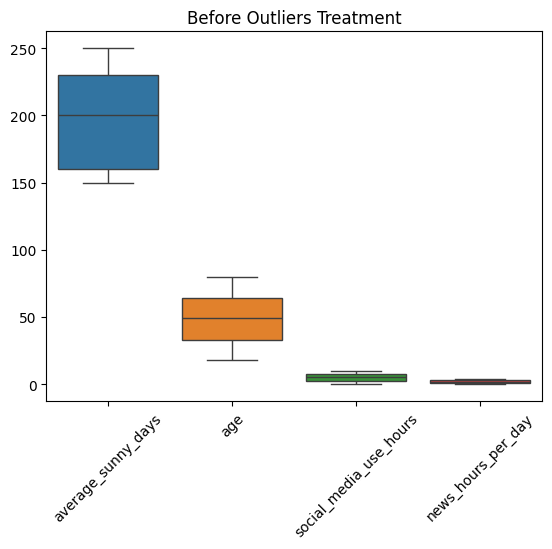

In [66]:
numeric_cols = df.select_dtypes(include='number').columns

sns.boxplot(data=df[numeric_cols])
plt.title("Before Outliers Treatment")
plt.xticks(rotation=45)
plt.show()

- There is no Outliers , So we don't have to remove it 

- Label Encoding the categorical features using mapping method

In [67]:
employment_map = {
    'Unemployed': 3,
    'Student': 2,
    'Retired': 1,
    'Employed': 0
}
marital_map = {
    'Single': 3,
    'Divorced': 2,
    'Widowed': 2,
    'Married': 0
}
education_map = {
    'High School': 3,
    'Bachelor': 2,
    'Master': 1,
    'PhD': 0
}
income_map = {
    '<1000': 4,
    '1000-2000': 3,
    '2000-3000': 2,
    '3000-5000': 1,
    '>5000': 0
}
loneliness_map = {
    'Frequent': 1,
    'Occasional': 0
}
anxiety_map = {
    'Severe': 2,
    'Moderate': 1,
    'Mild': 0
}
df['employment_status'] = df['employment_status'].map(employment_map)
df['marital_status'] = df['marital_status'].map(marital_map)
df['education_level'] = df['education_level'].map(education_map)
df['monthly_income'] = df['monthly_income'].map(income_map)
df['loneliness'] = df['loneliness'].map(loneliness_map)
df['anxiety_level'] = df['anxiety_level'].map(anxiety_map)


- Hot encoding the categorical data (country and gender)

In [68]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

- Split the data into features and target variable 

In [69]:
y = df['depression_severity']
df = df.drop(columns=['depression_severity'])

- Convert boolean columns to integers to prepare for standardization

In [70]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

- stander scaling the data for the variance to be 0 and the mean to be 0

In [71]:
scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/home/abdo/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [5]. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


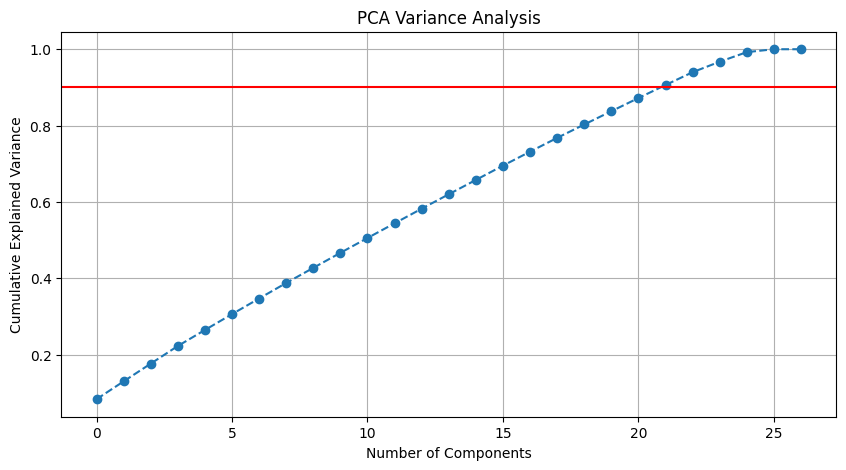

In [76]:
numeric_df = df.select_dtypes(include=[np.number])


X_scaled = scaler.fit_transform(numeric_df)

pca = PCA()
# Impute missing values so PCA can run (PCA does not accept NaN)
X_scaled = imputer.fit_transform(X_scaled)
pca.fit(X_scaled)


plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Analysis')
plt.axhline(y=0.90, color='r', linestyle='-') 
plt.grid()
plt.show()

pca_final = PCA(n_components=0.90)
X_pca = pca_final.fit_transform(X_scaled)

      

In [ ]:
print(X_pca)

[[ 2.23078478 -0.57466639 -0.48405368 ...  0.29120609 -0.28053694
  -1.49373114]
 [-1.03280244 -0.73187478  1.91578297 ...  0.63769453  0.87709531
  -0.42015773]
 [ 0.10520567  0.08326658  0.37431775 ...  0.43288628  1.4253497
   0.24072533]
 ...
 [-1.70257821 -1.04903671 -1.41397986 ...  0.62893513  0.46743039
   0.84612551]
 [-0.84696964 -0.65853498  2.2161261  ... -0.25536359 -1.7230601
  -0.51779833]
 [-0.92316534 -1.3660845   1.45003478 ...  0.49590202  0.29556887
   1.06134724]]


### PCA

- The blue curve shows cumulative explained variance vs number of principal components.
- The red horizontal line marks 90% explained variance; choose the smallest number of components where the curve crosses this line.
- `PCA(n_components=0.90)` automatically selects the minimum components that retain >= 90% of the variance.
- To see which number was chosen, run `print(pca_final.n_components_)` or check `X_pca.shape`.

Quick command to compute the crossing index manually:

`np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1`